In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import seaborn as sns


In [3]:
def run_random_forest_pipeline(file_path, target_column='bug', smote_ratio=0.8, n_estimators_list=[100,200]):
    """
    Runs SMOTE + undersampling + Random Forest pipeline with cross-validated hyperparameter tuning.
    Returns trained model and prints evaluation metrics.
    """
    # -------------------------
    # Load & preprocess
    # -------------------------
    df = pd.read_csv(file_path)
    df = df.dropna()
    df[target_column] = df[target_column].apply(lambda x: 0 if x==0 else 1)
    
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    print(f"\nDataset: {file_path}")
    print("Original class distribution:")
    print(y.value_counts())
    
    # -------------------------
    # Resample: SMOTE + Undersampling
    # -------------------------
    smote = SMOTE(sampling_strategy=smote_ratio, random_state=42)
    undersample = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
    resample_pipeline = Pipeline([('smote', smote), ('under', undersample)])
    X_res, y_res = resample_pipeline.fit_resample(X, y)
    
    print("Resampled class distribution:")
    print(pd.Series(y_res).value_counts())
    
    # -------------------------
    # Baseline Stratified K-Fold CV
    # -------------------------
    best_model = None
    best_score = 0
    best_params = {}
    
    for n_estimators in n_estimators_list:
        for max_depth in [None, 5, 10, 15]:
            rf = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
            scores = cross_val_score(rf, X_res, y_res, cv=5, scoring='f1')
            mean_score = np.mean(scores)
            if mean_score > best_score:
                best_score = mean_score
                best_model = rf
                best_params = {'n_estimators': n_estimators, 'max_depth': max_depth}

    print(f"Best RF params: {best_params}, CV F1: {best_score:.3f}")
    
    # -------------------------
    # Train final model
    # -------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
    )
    
    best_model.fit(X_train, y_train)
    
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    # -------------------------
    # Evaluation
    # -------------------------
    print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Testing Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
    
    print("\nClassification Report (Test Data):")
    print(classification_report(y_test, y_test_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {file_path}')
    plt.show()
    
    # -------------------------
    # Feature Importance
    # -------------------------
    importances = best_model.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]

    plt.figure(figsize=(12,6))
    plt.bar(X.columns[sorted_idx], importances[sorted_idx])
    plt.xticks(rotation=90)
    plt.title(f"Feature Importances - {file_path}")
    plt.show()
    
    return best_model



Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv
Original class distribution:
bug
0    1342
1     350
Name: count, dtype: int64


C:\Users\sodhi\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\sodhi\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\sodhi\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sodhi\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\sodhi\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

Resampled class distribution:
bug
0    1073
1    1073
Name: count, dtype: int64
Best RF params: {'n_estimators': 100, 'max_depth': 15}, CV F1: 0.822
Training Accuracy: 0.9289
Testing Accuracy:  0.8465

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       215
           1       0.84      0.86      0.85       215

    accuracy                           0.85       430
   macro avg       0.85      0.85      0.85       430
weighted avg       0.85      0.85      0.85       430



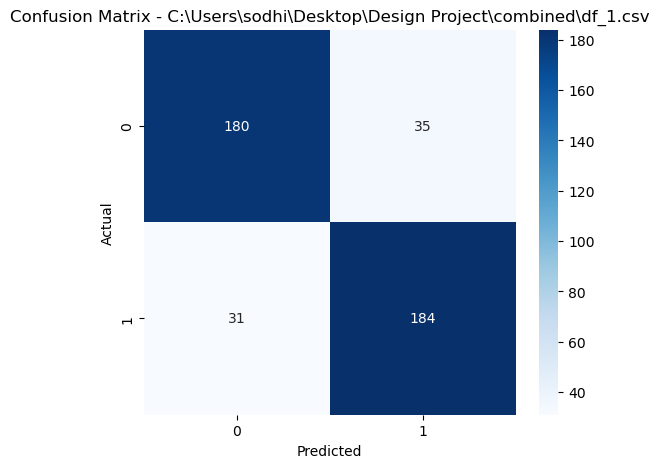

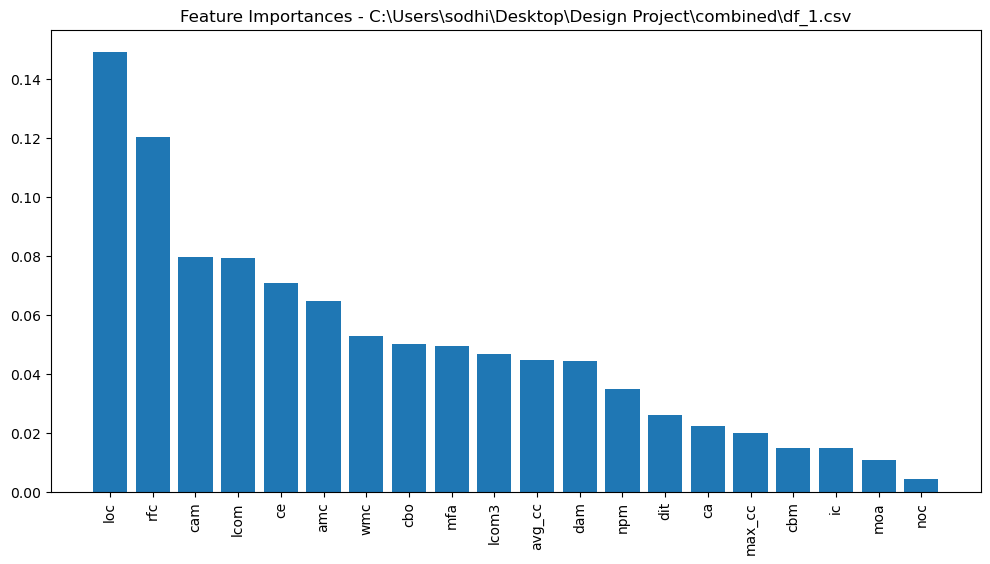


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv
Original class distribution:
bug
0    2222
1     562
Name: count, dtype: int64
Resampled class distribution:
bug
0    1777
1    1777
Name: count, dtype: int64
Best RF params: {'n_estimators': 200, 'max_depth': None}, CV F1: 0.811
Training Accuracy: 0.9166
Testing Accuracy:  0.8186

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.82      0.81      0.82       356
           1       0.81      0.83      0.82       355

    accuracy                           0.82       711
   macro avg       0.82      0.82      0.82       711
weighted avg       0.82      0.82      0.82       711



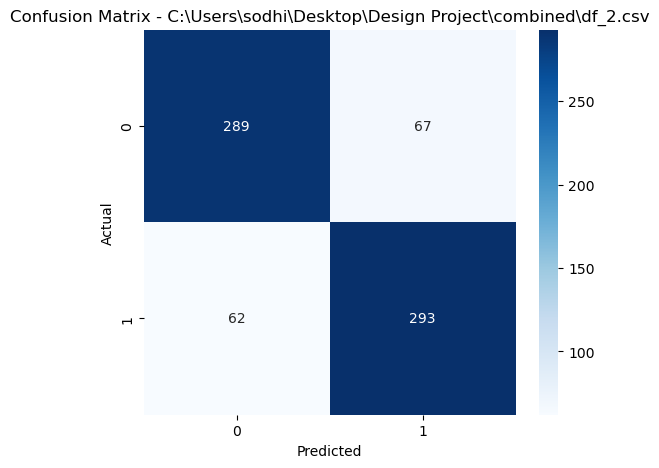

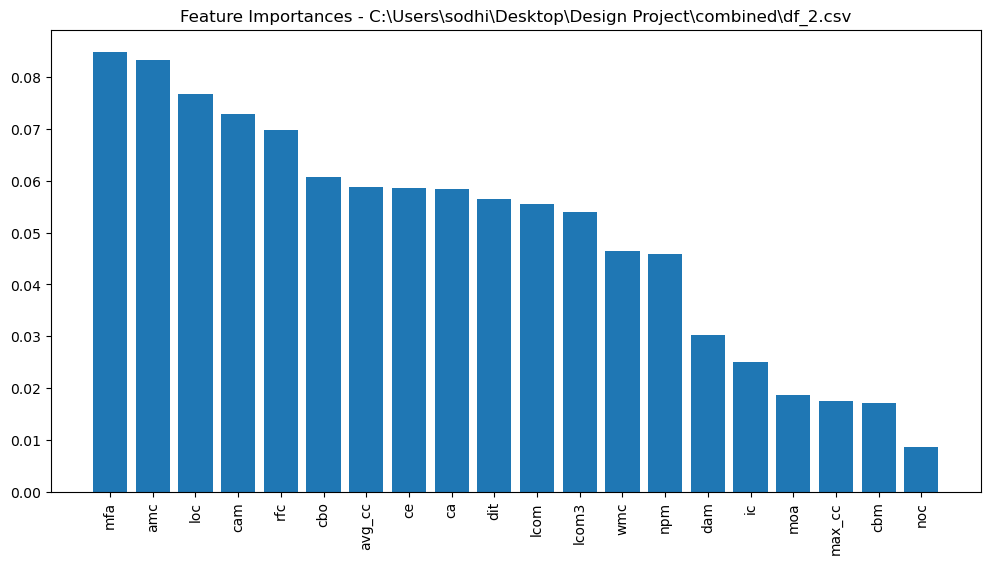


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv
Original class distribution:
bug
0    585
1    119
Name: count, dtype: int64
Resampled class distribution:
bug
0    468
1    468
Name: count, dtype: int64
Best RF params: {'n_estimators': 200, 'max_depth': None}, CV F1: 0.824
Training Accuracy: 0.9465
Testing Accuracy:  0.8617

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        94
           1       0.84      0.89      0.87        94

    accuracy                           0.86       188
   macro avg       0.86      0.86      0.86       188
weighted avg       0.86      0.86      0.86       188



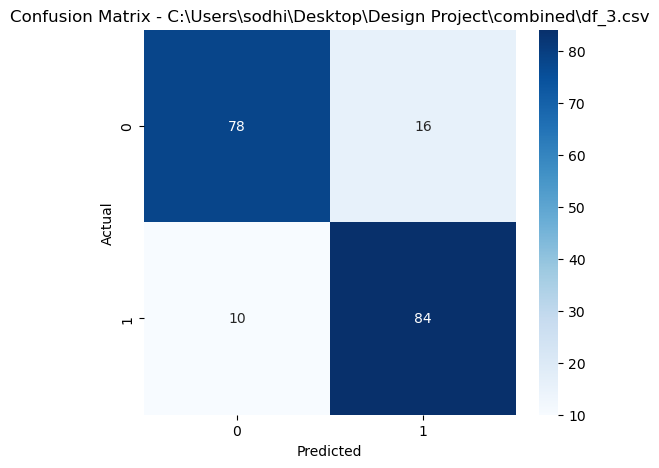

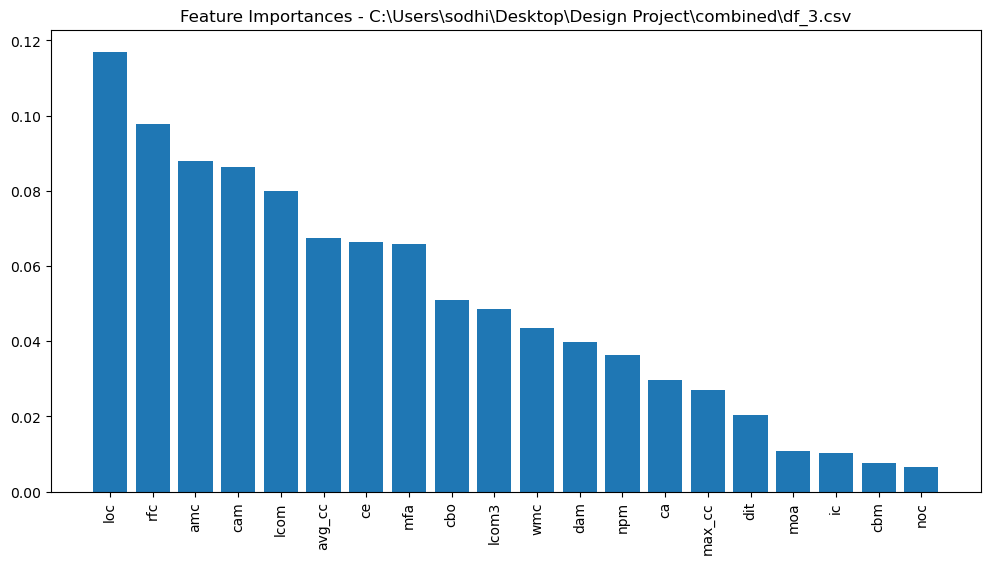


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv
Original class distribution:
bug
0    1446
1     303
Name: count, dtype: int64
Resampled class distribution:
bug
0    1156
1    1156
Name: count, dtype: int64
Best RF params: {'n_estimators': 200, 'max_depth': None}, CV F1: 0.862
Training Accuracy: 0.9448
Testing Accuracy:  0.8639

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       232
           1       0.84      0.89      0.87       231

    accuracy                           0.86       463
   macro avg       0.87      0.86      0.86       463
weighted avg       0.87      0.86      0.86       463



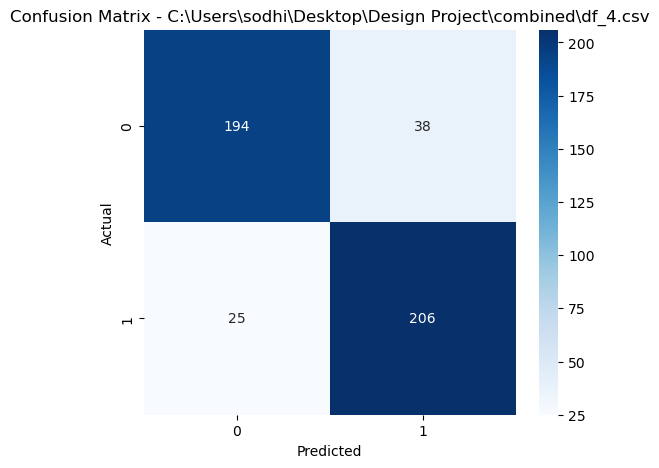

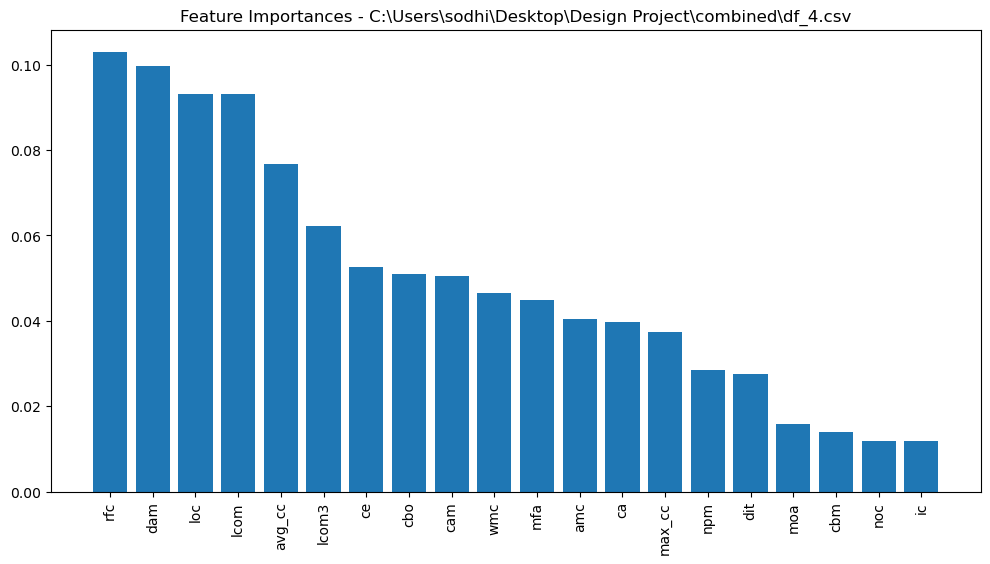


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv
Original class distribution:
bug
1    260
0    189
Name: count, dtype: int64
Resampled class distribution:
bug
0    208
1    208
Name: count, dtype: int64
Best RF params: {'n_estimators': 100, 'max_depth': 10}, CV F1: 0.634
Training Accuracy: 0.8102
Testing Accuracy:  0.6310

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.60      0.81      0.69        42
           1       0.70      0.45      0.55        42

    accuracy                           0.63        84
   macro avg       0.65      0.63      0.62        84
weighted avg       0.65      0.63      0.62        84



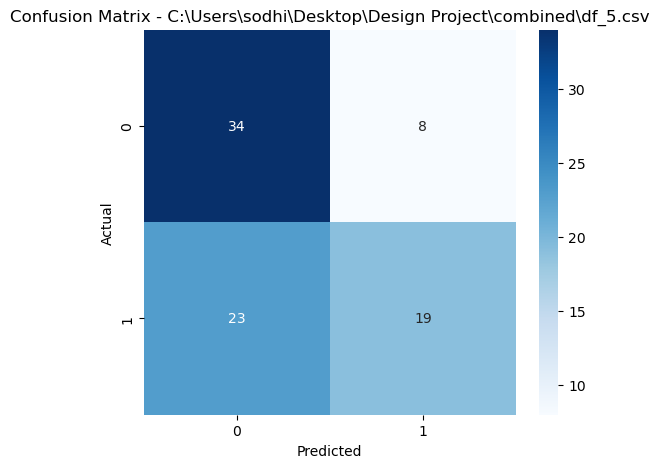

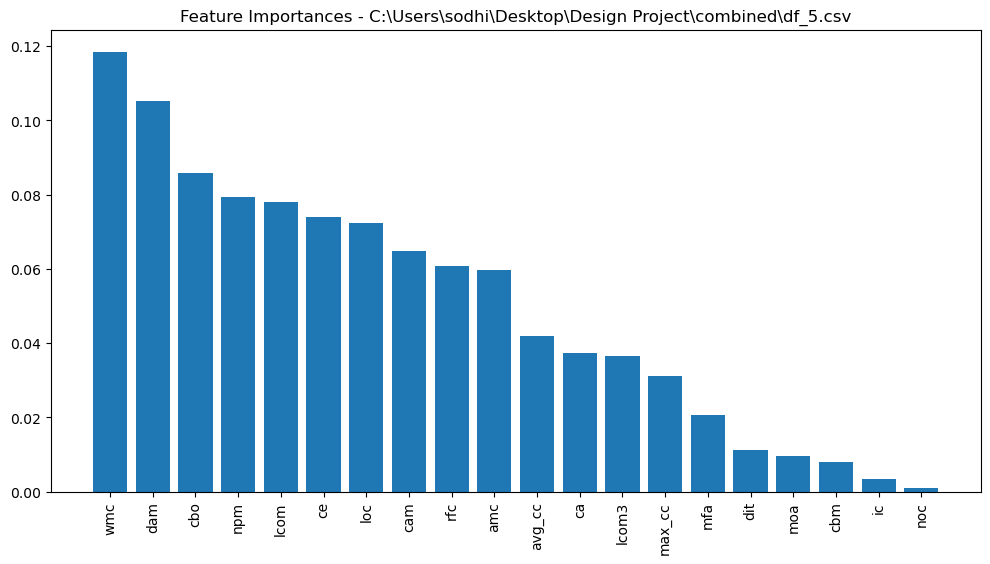

In [5]:
file_paths = [
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv"
]

models = []
for fp in file_paths:
    model = run_random_forest_pipeline(fp)
    models.append(model)


In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold


In [13]:
def run_random_forest_gridsearch(file_path, target_column='bug', smote_ratio=0.8):
    """
    Random Forest pipeline with SMOTE + undersampling + GridSearchCV.
    Prints evaluation metrics, feature importance, confusion matrix, and plots.
    """
    # -------------------------
    # Step 0: Load & preprocess
    # -------------------------
    df = pd.read_csv(file_path)
    df = df.dropna()
    df[target_column] = df[target_column].apply(lambda x: 0 if x==0 else 1)

    X = df.drop(columns=[target_column])
    y = df[target_column]

    print(f"\nDataset: {file_path}")
    print("Original class distribution:")
    print(y.value_counts())

    # -------------------------
    # Step 1: Define Pipeline
    # -------------------------
    pipeline = Pipeline([
        ('smote', SMOTE(sampling_strategy=smote_ratio, random_state=42)),
        ('under', RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
        ('rf', RandomForestClassifier(min_samples_leaf=5, random_state=42, n_jobs=-1))
    ])

    # -------------------------
    # Step 2: Define Grid Search Parameters
    # -------------------------
    param_grid = {
        'rf__n_estimators': [100, 200, 300],
        'rf__max_depth': [None, 5, 10, 15]
    }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=2,
        refit=True
    )

    # -------------------------
    # Step 3: Fit GridSearchCV
    # -------------------------
    grid_search.fit(X, y)
    best_model = grid_search.best_estimator_

    print("\nBest Parameters:", grid_search.best_params_)
    print("Best CV F1 Score:", grid_search.best_score_)

    # -------------------------
    # Step 4: Train/Test Split for Final Evaluation
    # -------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    best_model.fit(X_train, y_train)
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # -------------------------
    # Step 5: Accuracy and Classification Report
    # -------------------------
    print(f"\nTraining Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Testing Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
    print("\nClassification Report (Test Data):")
    print(classification_report(y_test, y_test_pred))

    # -------------------------
    # Step 6: Confusion Matrix
    # -------------------------
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {file_path}')
    plt.show()

    # -------------------------
    # Step 7: Feature Importance
    # -------------------------
    importances = best_model.named_steps['rf'].feature_importances_
    sorted_idx = np.argsort(importances)[::-1]

    plt.figure(figsize=(12,6))
    plt.bar(X.columns[sorted_idx], importances[sorted_idx])
    plt.xticks(rotation=90)
    plt.title(f"Feature Importances - {file_path}")
    plt.show()

    return best_model, grid_search.best_params_, grid_search.best_score_



Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv
Original class distribution:
bug
0    1342
1     350
Name: count, dtype: int64
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'rf__max_depth': 10, 'rf__n_estimators': 300}
Best CV F1 Score: 0.5409482019657287

Training Accuracy: 0.8862
Testing Accuracy:  0.7729

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.87      0.84      0.85       269
           1       0.46      0.53      0.49        70

    accuracy                           0.77       339
   macro avg       0.66      0.68      0.67       339
weighted avg       0.79      0.77      0.78       339



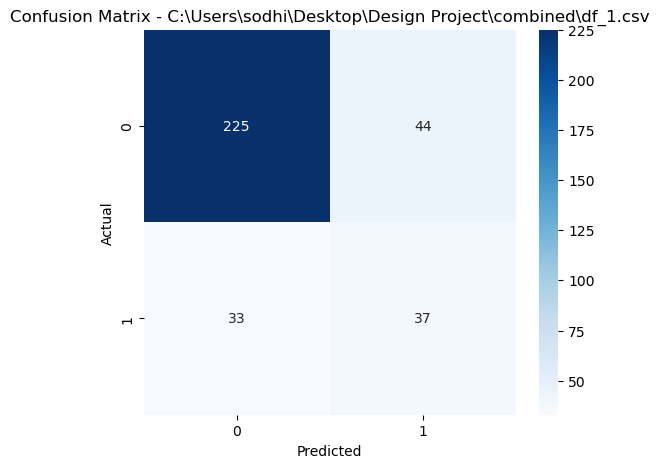

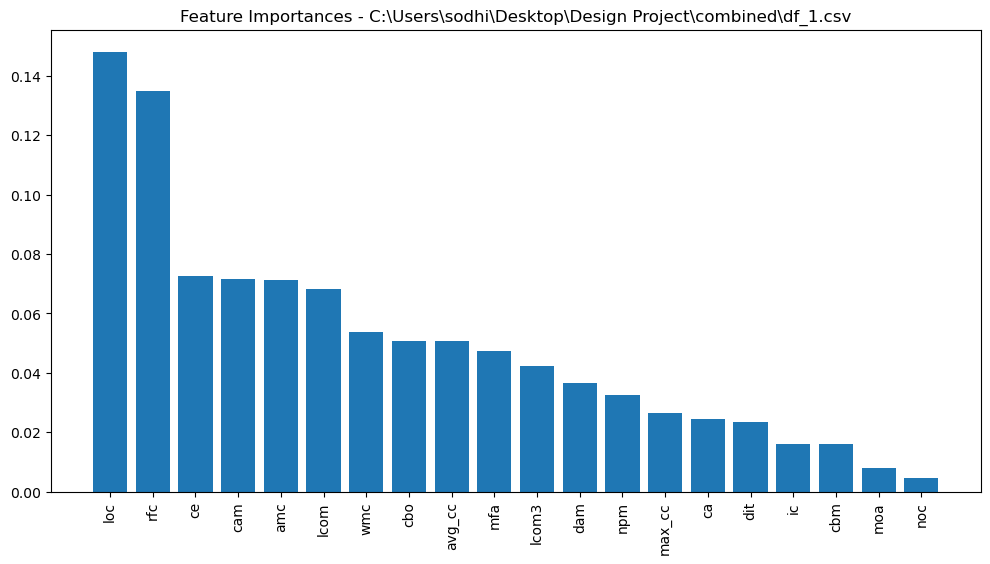


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv
Original class distribution:
bug
0    2222
1     562
Name: count, dtype: int64
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'rf__max_depth': None, 'rf__n_estimators': 300}
Best CV F1 Score: 0.45363868363610227

Training Accuracy: 0.8824
Testing Accuracy:  0.7684

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.87      0.84      0.85       445
           1       0.43      0.50      0.46       112

    accuracy                           0.77       557
   macro avg       0.65      0.67      0.66       557
weighted avg       0.78      0.77      0.77       557



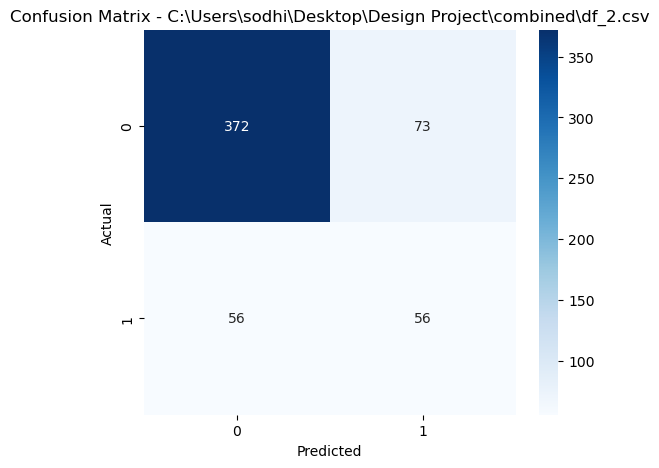

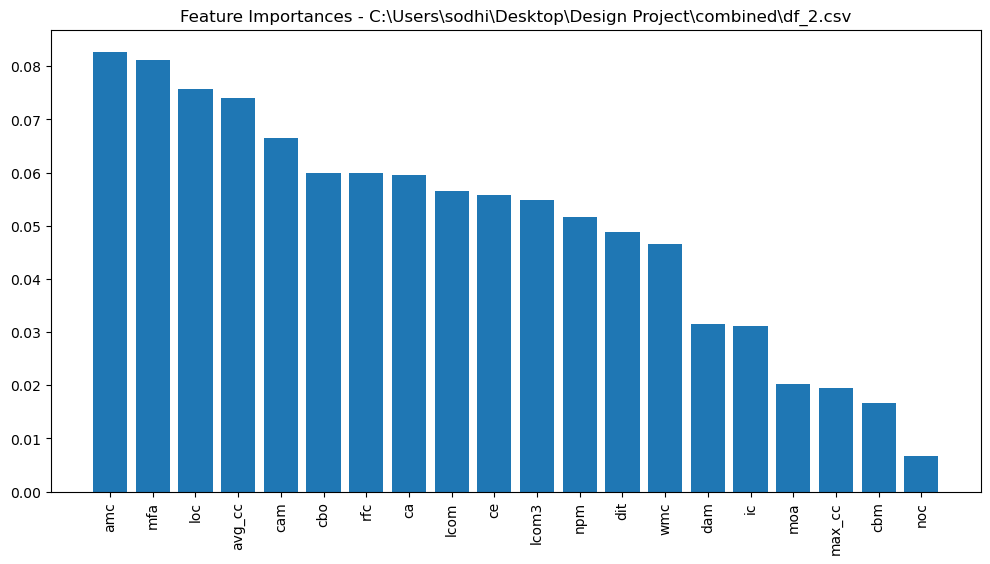


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv
Original class distribution:
bug
0    585
1    119
Name: count, dtype: int64
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'rf__max_depth': 5, 'rf__n_estimators': 100}
Best CV F1 Score: 0.3887496813761874

Training Accuracy: 0.7922
Testing Accuracy:  0.7092

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.92      0.71      0.80       117
           1       0.33      0.71      0.45        24

    accuracy                           0.71       141
   macro avg       0.63      0.71      0.63       141
weighted avg       0.82      0.71      0.74       141



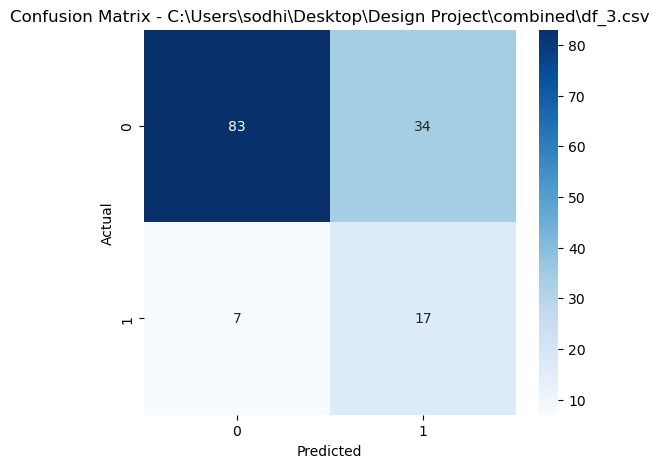

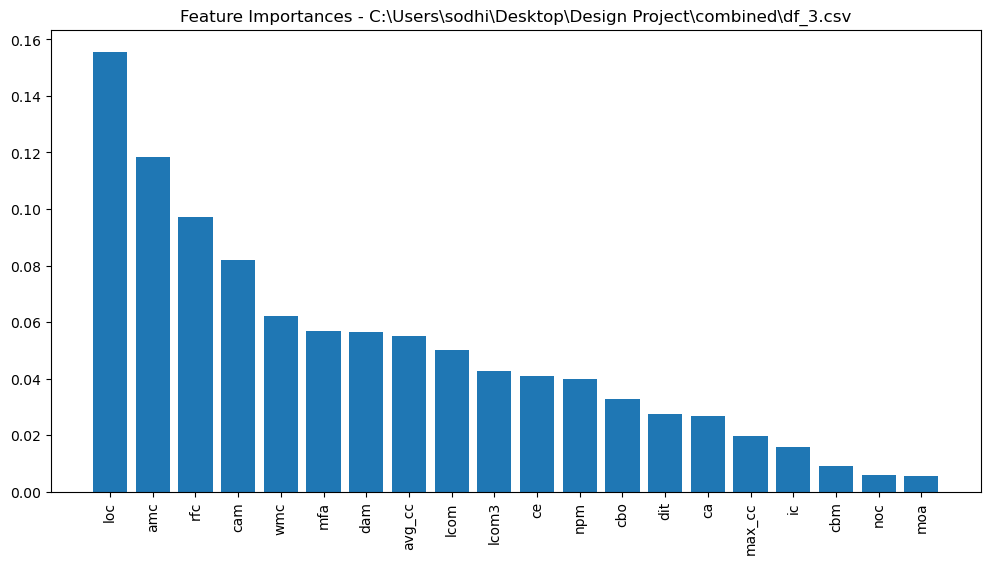


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv
Original class distribution:
bug
0    1446
1     303
Name: count, dtype: int64
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'rf__max_depth': 10, 'rf__n_estimators': 300}
Best CV F1 Score: 0.5111706811706812

Training Accuracy: 0.9071
Testing Accuracy:  0.7743

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       289
           1       0.38      0.48      0.42        61

    accuracy                           0.77       350
   macro avg       0.63      0.66      0.64       350
weighted avg       0.80      0.77      0.78       350



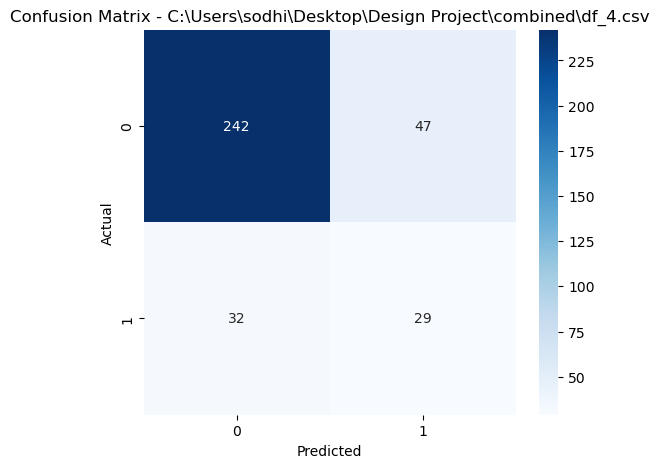

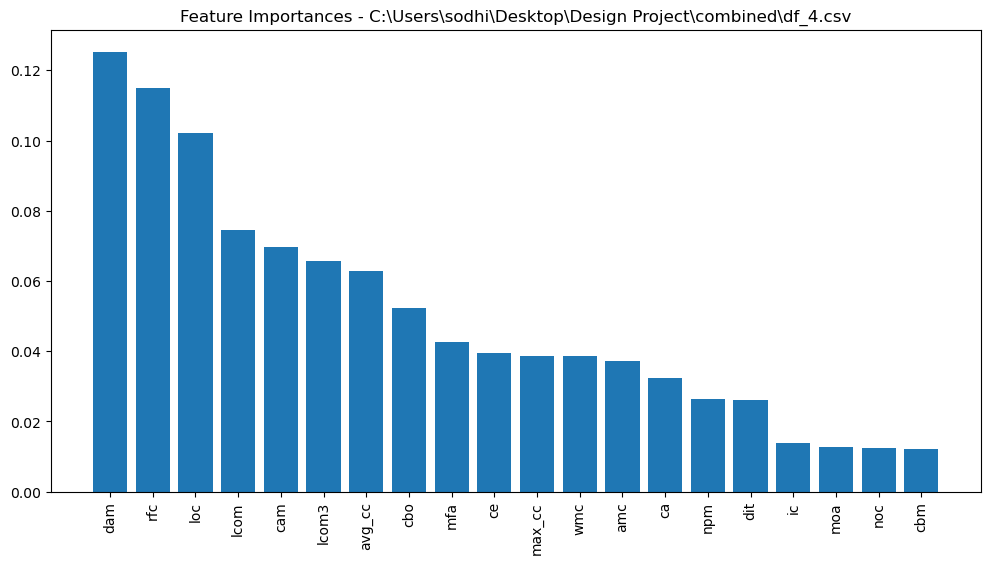


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv
Original class distribution:
bug
1    260
0    189
Name: count, dtype: int64
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'rf__max_depth': 5, 'rf__n_estimators': 200}
Best CV F1 Score: 0.6175154859337467

Training Accuracy: 0.7354
Testing Accuracy:  0.6667

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.57      0.87      0.69        38
           1       0.84      0.52      0.64        52

    accuracy                           0.67        90
   macro avg       0.71      0.69      0.67        90
weighted avg       0.73      0.67      0.66        90



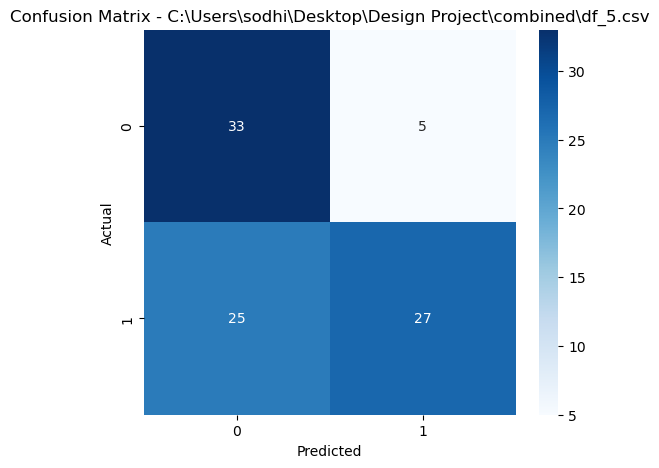

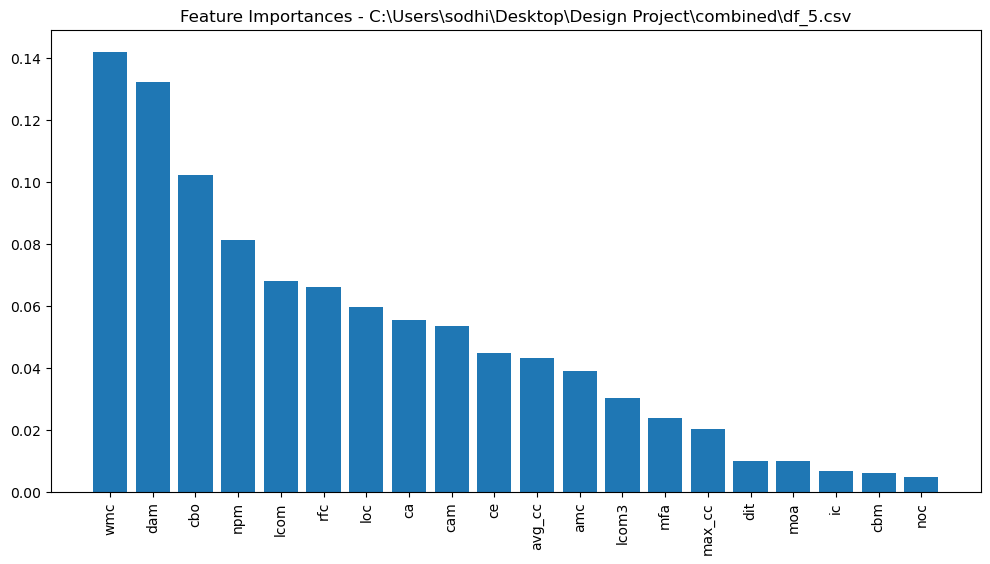

In [15]:
file_paths = [
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv"
]

models = []
for fp in file_paths:
    model = run_random_forest_gridsearch(fp)
    models.append(model)


In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

def run_rf_hybrid_pipeline(file_path, target_column='bug', smote_ratio=0.8):
    """
    Hybrid Random Forest pipeline with:
    1. GridSearchCV (SMOTE + undersampling inside CV)
    2. Retraining on full resampled data
    3. Evaluation and feature importance
    """
    # -------------------------
    # Load and preprocess
    # -------------------------
    df = pd.read_csv(file_path)
    df = df.dropna()
    df[target_column] = df[target_column].apply(lambda x: 0 if x == 0 else 1)

    X = df.drop(columns=[target_column])
    y = df[target_column]

    print(f"\nDataset: {file_path}")
    print("Original class distribution:")
    print(y.value_counts())

    # -------------------------
    # Define pipeline for CV (SMOTE + Under + RF)
    # -------------------------
    smote = SMOTE(sampling_strategy=smote_ratio, random_state=42)
    undersample = RandomUnderSampler(sampling_strategy=1.0, random_state=42)

    rf = RandomForestClassifier(random_state=42, min_samples_leaf=5, n_jobs=-1)

    pipeline = Pipeline([
        ('smote', smote),
        ('under', undersample),
        ('rf', rf)
    ])

    # -------------------------
    # Define parameter grid for GridSearchCV
    # -------------------------
    param_grid = {
        'rf__n_estimators': [100, 200],
        'rf__max_depth': [None, 5, 10, 15],
        'rf__criterion': ['gini', 'entropy']
    }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    # -------------------------
    # Run grid search on original data
    # -------------------------
    grid_search.fit(X, y)
    print("\nBest Parameters (GridSearchCV):")
    print(grid_search.best_params_)
    print(f"Best CV F1 (macro): {grid_search.best_score_:.3f}")

    # -------------------------
    # Reapply SMOTE + undersampling on full data (hybrid step)
    # -------------------------
    smote = SMOTE(sampling_strategy=smote_ratio, random_state=42)
    undersample = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
    X_res, y_res = Pipeline([('smote', smote), ('under', undersample)]).fit_resample(X, y)

    print("\nResampled class distribution:")
    print(pd.Series(y_res).value_counts())

    # -------------------------
    # Train final model using best params
    # -------------------------
    best_params = grid_search.best_params_
    rf_final = RandomForestClassifier(
        n_estimators=best_params['rf__n_estimators'],
        max_depth=best_params['rf__max_depth'],
        criterion=best_params['rf__criterion'],
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
    )

    rf_final.fit(X_train, y_train)

    # -------------------------
    # Evaluation
    # -------------------------
    y_train_pred = rf_final.predict(X_train)
    y_test_pred = rf_final.predict(X_test)

    print(f"\nTraining Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Testing Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
    print("\nClassification Report (Test Data):")
    print(classification_report(y_test, y_test_pred))

    # -------------------------
    # Confusion Matrix
    # -------------------------
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {file_path}')
    plt.show()

    # -------------------------
    # Feature Importance
    # -------------------------
    importances = rf_final.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]

    plt.figure(figsize=(12, 6))
    plt.bar(X.columns[sorted_idx], importances[sorted_idx])
    plt.xticks(rotation=90)
    plt.title(f"Feature Importances - {file_path}")
    plt.show()

    return rf_final, grid_search.best_params_



Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv
Original class distribution:
bug
0    1342
1     350
Name: count, dtype: int64
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters (GridSearchCV):
{'rf__criterion': 'entropy', 'rf__max_depth': 10, 'rf__n_estimators': 200}
Best CV F1 (macro): 0.700

Resampled class distribution:
bug
0    1073
1    1073
Name: count, dtype: int64

Training Accuracy: 0.9202
Testing Accuracy:  0.8465

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       215
           1       0.84      0.86      0.85       215

    accuracy                           0.85       430
   macro avg       0.85      0.85      0.85       430
weighted avg       0.85      0.85      0.85       430



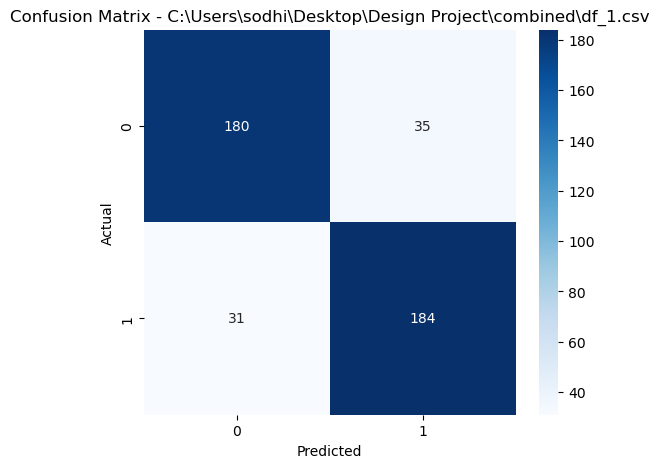

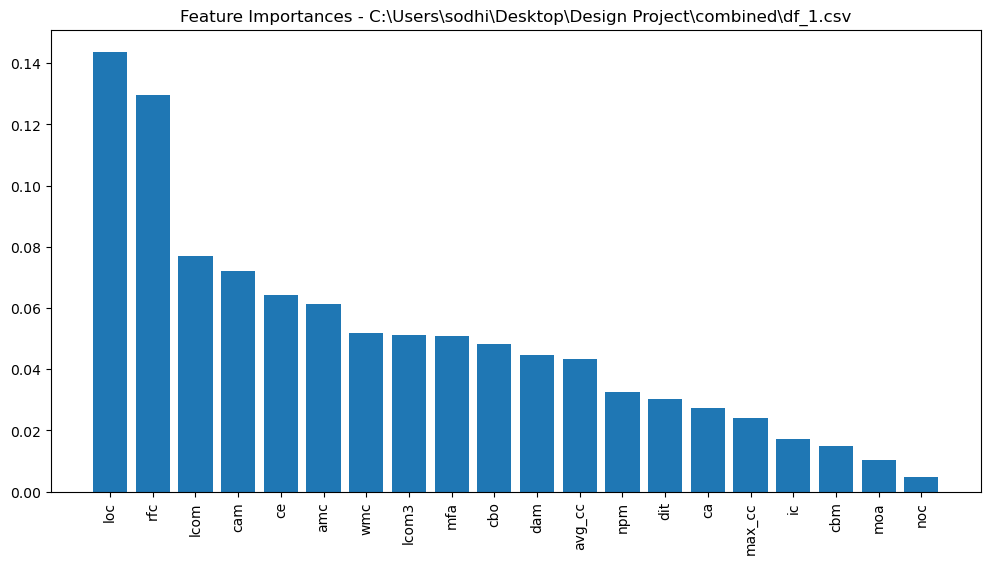


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv
Original class distribution:
bug
0    2222
1     562
Name: count, dtype: int64
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters (GridSearchCV):
{'rf__criterion': 'gini', 'rf__max_depth': 15, 'rf__n_estimators': 200}
Best CV F1 (macro): 0.648

Resampled class distribution:
bug
0    1777
1    1777
Name: count, dtype: int64

Training Accuracy: 0.9177
Testing Accuracy:  0.8214

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       356
           1       0.82      0.82      0.82       355

    accuracy                           0.82       711
   macro avg       0.82      0.82      0.82       711
weighted avg       0.82      0.82      0.82       711



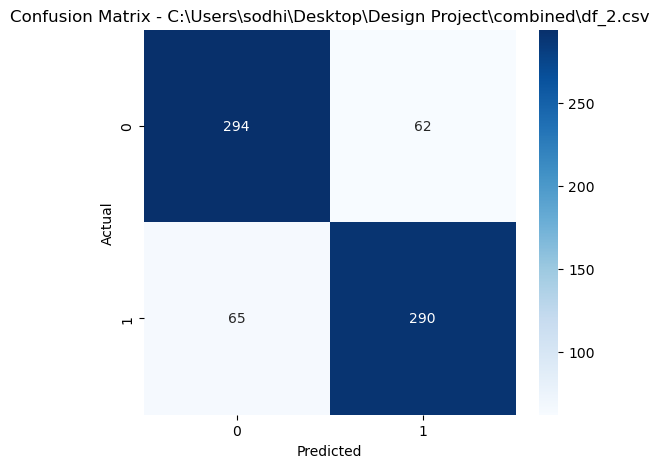

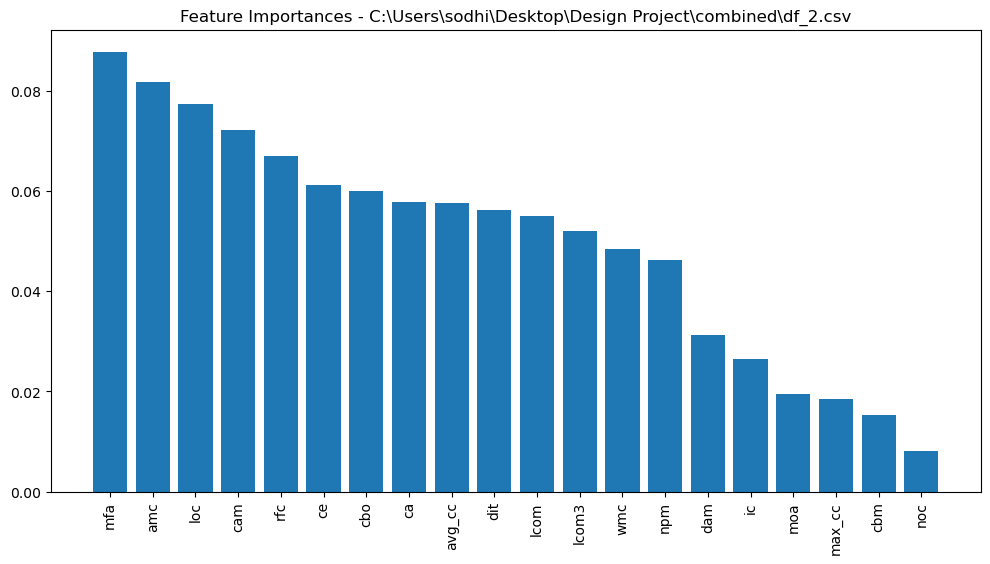


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv
Original class distribution:
bug
0    585
1    119
Name: count, dtype: int64
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters (GridSearchCV):
{'rf__criterion': 'entropy', 'rf__max_depth': 10, 'rf__n_estimators': 200}
Best CV F1 (macro): 0.609

Resampled class distribution:
bug
0    468
1    468
Name: count, dtype: int64

Training Accuracy: 0.9398
Testing Accuracy:  0.8511

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        94
           1       0.83      0.88      0.86        94

    accuracy                           0.85       188
   macro avg       0.85      0.85      0.85       188
weighted avg       0.85      0.85      0.85       188



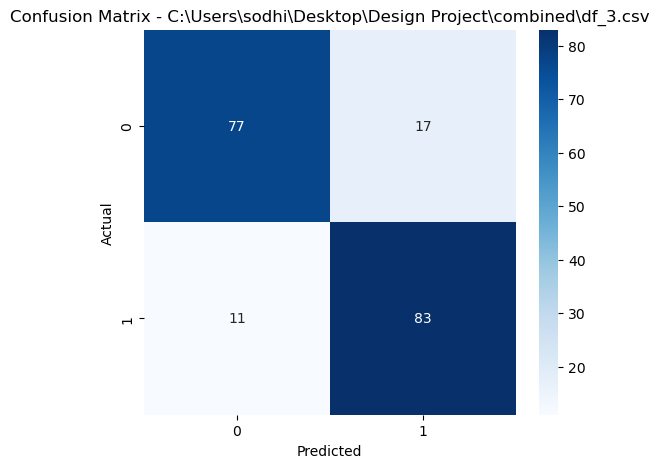

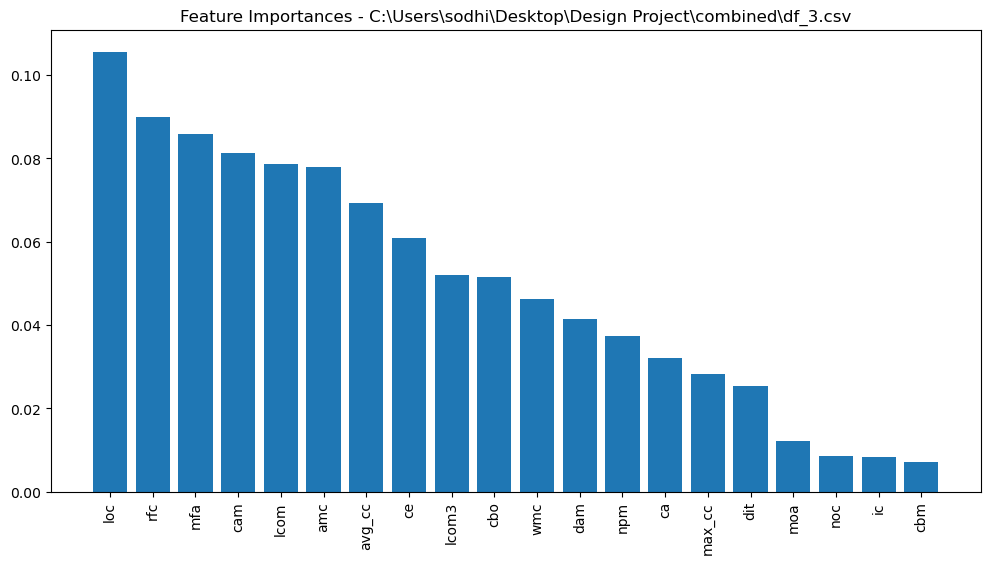


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv
Original class distribution:
bug
0    1446
1     303
Name: count, dtype: int64
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters (GridSearchCV):
{'rf__criterion': 'entropy', 'rf__max_depth': None, 'rf__n_estimators': 100}
Best CV F1 (macro): 0.687

Resampled class distribution:
bug
0    1156
1    1156
Name: count, dtype: int64

Training Accuracy: 0.9497
Testing Accuracy:  0.8683

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.90      0.83      0.86       232
           1       0.84      0.91      0.87       231

    accuracy                           0.87       463
   macro avg       0.87      0.87      0.87       463
weighted avg       0.87      0.87      0.87       463



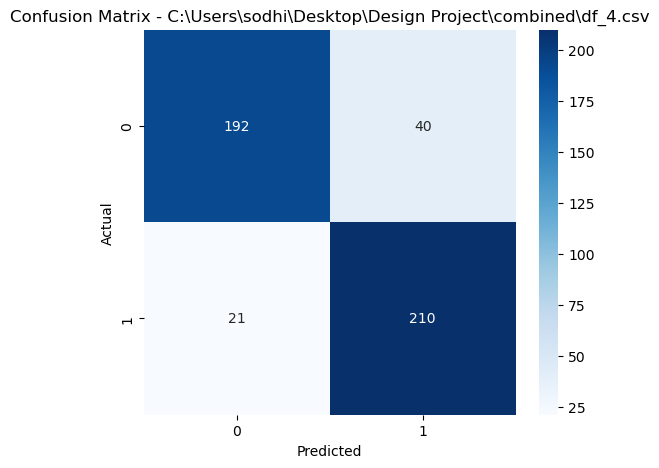

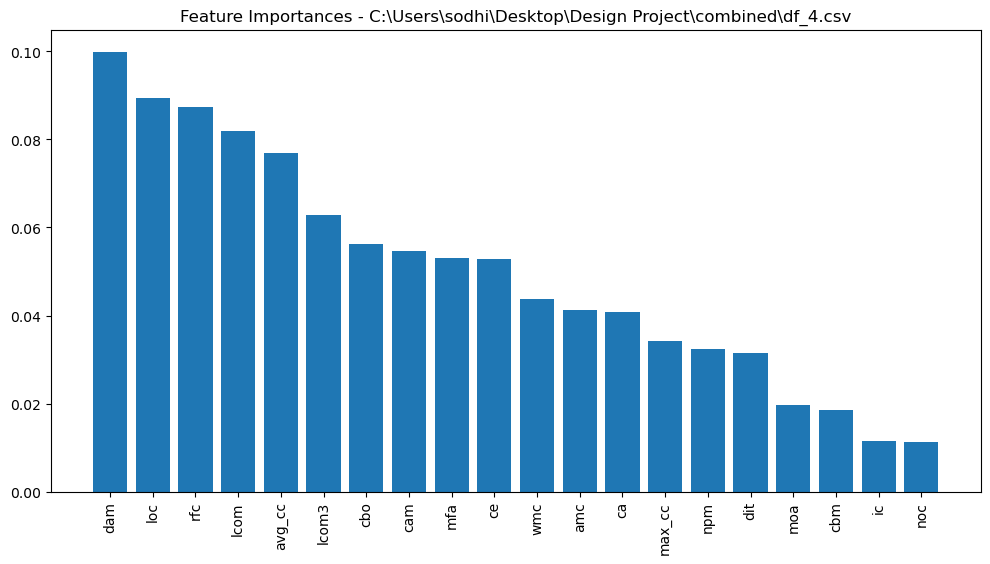


Dataset: C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv
Original class distribution:
bug
1    260
0    189
Name: count, dtype: int64
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters (GridSearchCV):
{'rf__criterion': 'gini', 'rf__max_depth': 5, 'rf__n_estimators': 200}
Best CV F1 (macro): 0.631

Resampled class distribution:
bug
0    208
1    208
Name: count, dtype: int64

Training Accuracy: 0.7892
Testing Accuracy:  0.6548

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.61      0.86      0.71        42
           1       0.76      0.45      0.57        42

    accuracy                           0.65        84
   macro avg       0.69      0.65      0.64        84
weighted avg       0.69      0.65      0.64        84



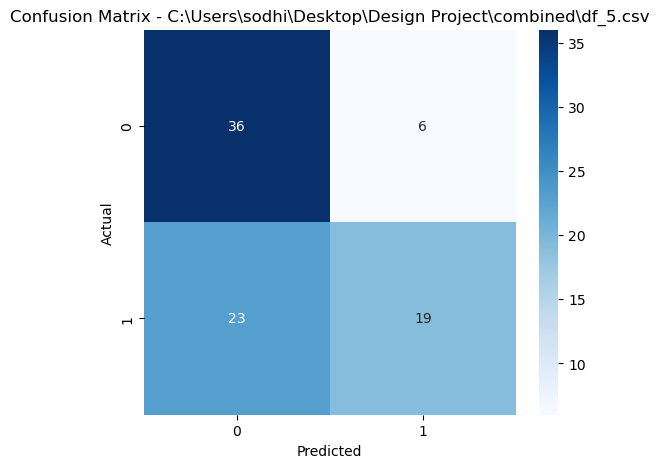

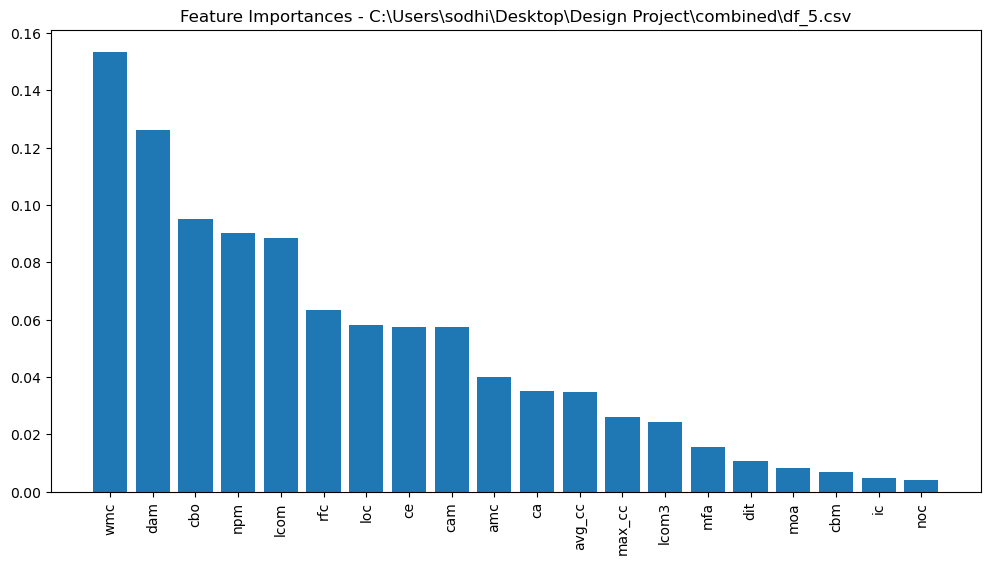

In [19]:
file_paths = [
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_1.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_2.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_3.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_4.csv",
    r"C:\Users\sodhi\Desktop\Design Project\combined\df_5.csv"
]

models = []
for fp in file_paths:
    model = run_rf_hybrid_pipeline(fp)
    models.append(model)
